# Tugas - Klasifikasi dengan Decision Tree

| Nama | NRP |
|------|-----|
| Mahardika Indra Pratama Ilyasa | 5054251045 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model Decision Tree Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Link dataset akan diinformasikan terpisah]

Tujuan utama dari tugas ini adalah memahami cara kerja Decision Tree secara praktik, khususnya:
1. Perbedaan hasil antara kriteria split Gini Impurity dan Entropy
2. Pengaruh regularisasi (max_depth) terhadap gejala overfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model.
3. Eksperimen Model
   - Bangun model Decision Tree dengan kriteria Gini dan Entropy.
   - Lakukan eksperimen regularisasi dengan variasi nilai max_depth.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [ ]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

from kagglehub import KaggleDatasetAdapter
path = kagglehub.dataset_download("abbas829/bankruptcy")
print("Dataset berhasil diunduh dari: ", path)

files = os.listdir(path)
csv_filename = [f for f in files if f.endswith('.csv')][0]
csv_path = os.path.join(path, csv_filename)
df = pd.read_csv(csv_path)


Using Colab cache for faster access to the 'bankruptcy' dataset.
Dataset berhasil diunduh dari:  /kaggle/input/bankruptcy


In [ ]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
csv_path = "bankruptcy.csv"
print("Ukuran dataset: ", df.shape)
print("=====\n5 data pertama: ")
print(df.head())
print("=====\nInfo dataset: ")
print(df.info())
print("=====\nStatistik deskriptif: ")
print(df.describe())
print("=====\nJumlah missing value: ")
print(df.isnull().sum())

Ukuran dataset:  (6819, 96)
=====
5 data pertama: 
   Bankrupt?   ROA(C) before interest and depreciation before interest  \
0          1                                           0.370594          
1          1                                           0.464291          
2          1                                           0.426071          
3          1                                           0.399844          
4          1                                           0.465022          

    ROA(A) before interest and % after tax  \
0                                 0.424389   
1                                 0.538214   
2                                 0.499019   
3                                 0.451265   
4                                 0.538432   

    ROA(B) before interest and depreciation after tax  \
0                                           0.405750    
1                                           0.516730    
2                                           0.472295    

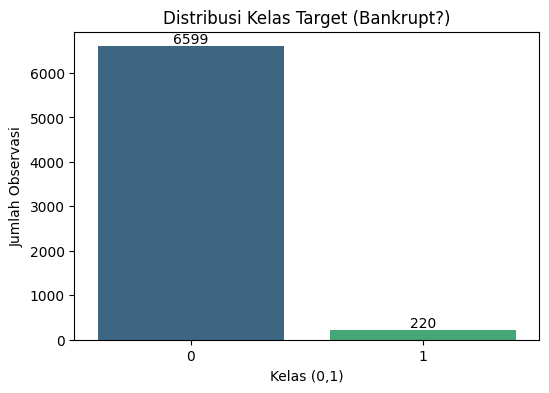

Persentase distribusi kelas target:
Bankrupt?
0    96.77372
1     3.22628
Name: proportion, dtype: float64


In [ ]:
# Tampilkan distribusi kelas target dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
# Tentukan kolom target yang benar secara eksplisit
target_col = 'Bankrupt?'  # atau gunakan df.columns[0] jika kolom pertama

plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x=target_col, hue=target_col, palette='viridis', legend=False)
plt.title(f'Distribusi Kelas Target ({target_col})')
plt.xlabel('Kelas (0,1)')
plt.ylabel('Jumlah Observasi')

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.show()

print("Persentase distribusi kelas target:")
print(df[target_col].value_counts(normalize=True) * 100)

Memilih jumlah fitur dengan korelasi > 0.25: 6
Daftar fitur terpilih:
-  Net Income to Total Assets (Korelasi: 0.3155)
-  ROA(A) before interest and % after tax (Korelasi: 0.2829)
-  ROA(B) before interest and depreciation after tax (Korelasi: 0.2731)
-  ROA(C) before interest and depreciation before interest (Korelasi: 0.2608)
-  Net worth/Assets (Korelasi: 0.2502)
-  Debt ratio % (Korelasi: 0.2502)


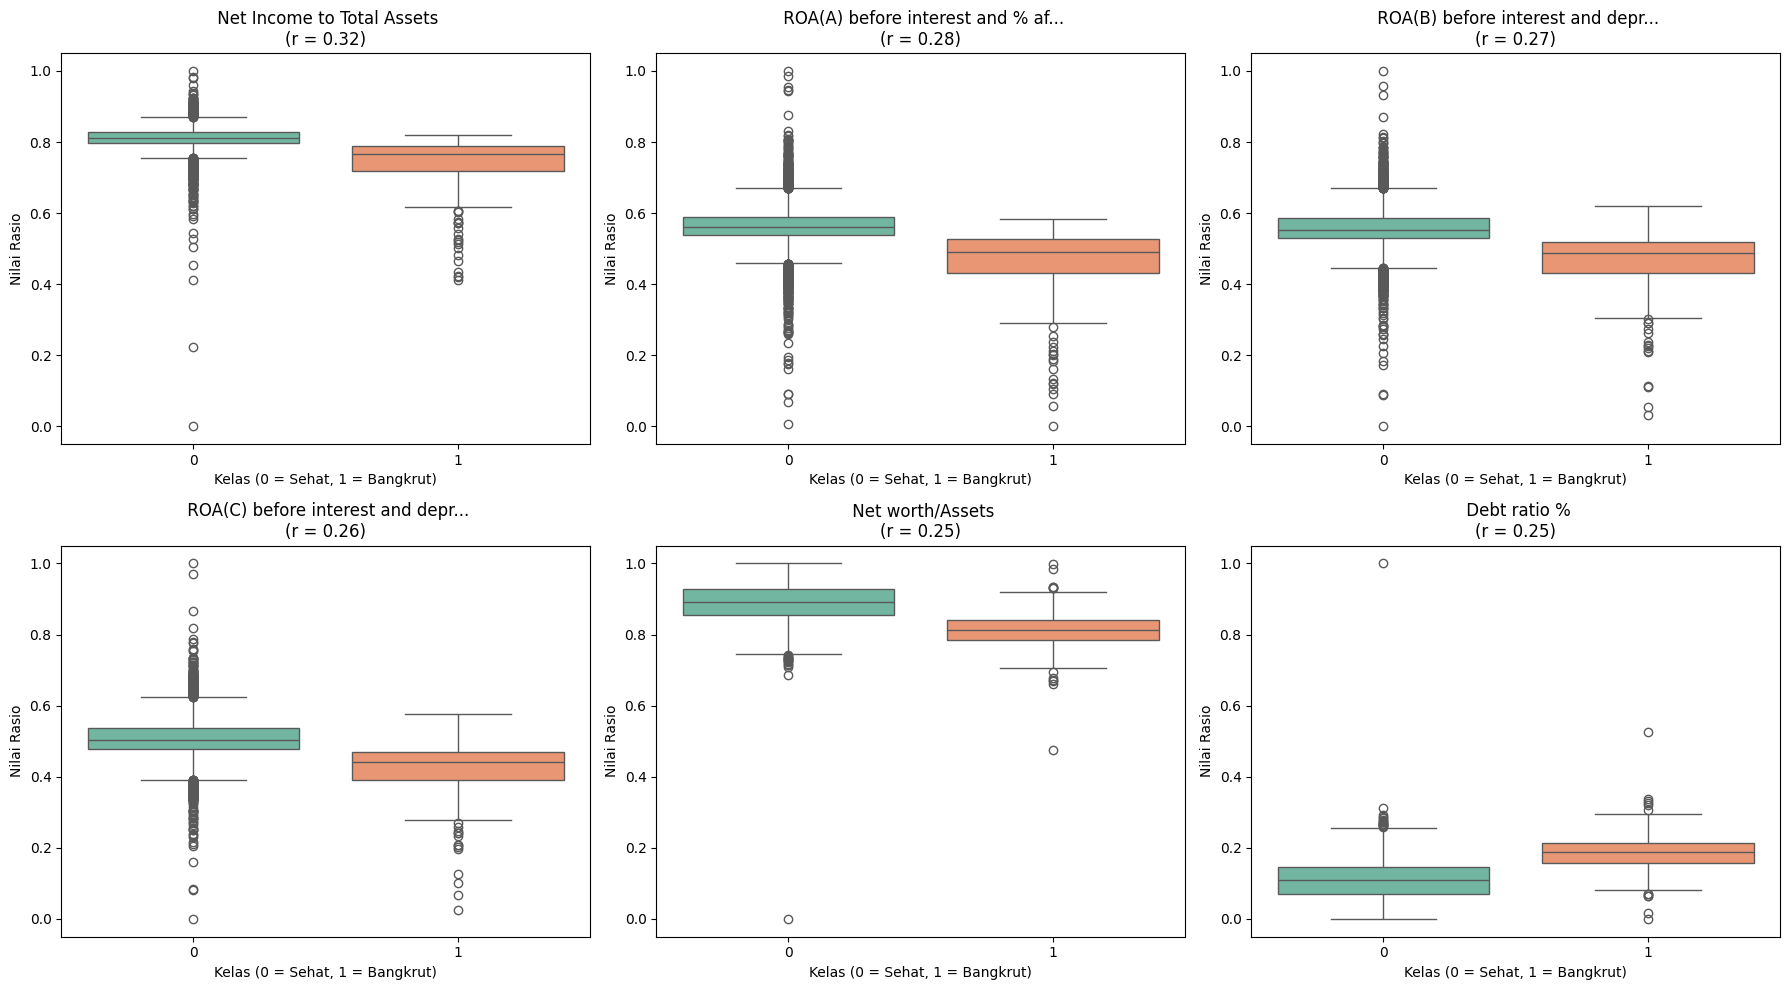

In [ ]:
# Tampilkan distribusi atau hubungan antar fitur (histogram, boxplot, atau pairplot), dibedakan berdasarkan kelas target.
# Ini membantu melihat apakah ada fitur yang punya batas pemisah yang jelas antar kelas.
target_col = 'Bankrupt?'

# Hitung nilai korelasi absolut terhadap target
corr_with_target = df.corr()[target_col].abs().sort_values(ascending=False)

# Filter fitur yang memiliki nilai korelasi > 0.25
selected_features = corr_with_target[(corr_with_target > 0.25) & (corr_with_target.index != target_col)].index.tolist()

print(f"Memilih jumlah fitur dengan korelasi > 0.25: {len(selected_features)}")
print("Daftar fitur terpilih:")
for f in selected_features:
    print(f"- {f} (Korelasi: {corr_with_target[f]:.4f})")

# Boxplot untuk fitur-fitur terpilih
num_features = len(selected_features)
cols_per_row = 3
rows = (num_features + cols_per_row - 1) // cols_per_row

fig, axes = plt.subplots(rows, cols_per_row, figsize=(18, 5 * rows))
axes = axes.flatten()

for i, col in enumerate(selected_features):
    sns.boxplot(data=df, x=target_col, y=col, hue = target_col, ax=axes[i], palette='Set2', legend = False)
    title_name = col if len(col) <= 35 else col[:32] + '...'
    axes[i].set_title(f'{title_name}\n(r = {corr_with_target[col]:.2f})')
    axes[i].set_xlabel('Kelas (0 = Sehat, 1 = Bangkrut)')
    axes[i].set_ylabel('Nilai Rasio')

# Hapus subplot kosong jika ada
for i in range(num_features, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

Total seluruh fitur              : 95
Fitur dengan MI >= 0.020         : 33 fitur
Fitur dengan MI >= 0.005         : 65 fitur
Fitur dengan MI < 0.005          : 30 fitur


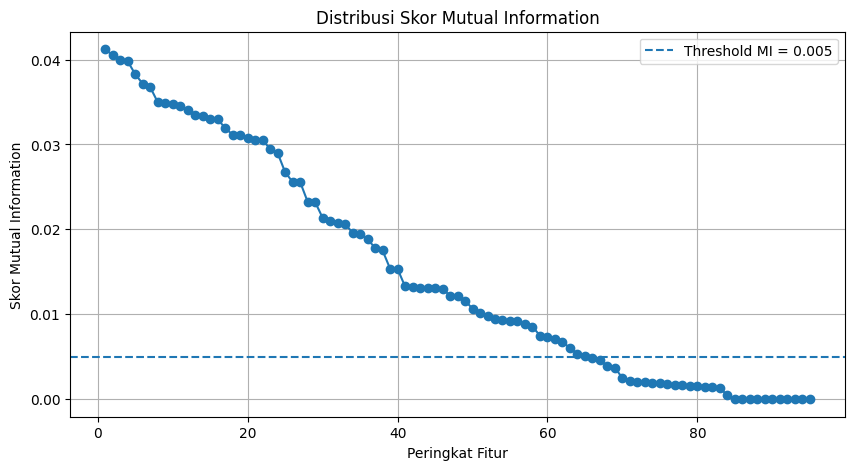

In [ ]:
target_col = 'Bankrupt?'

# Pisahkan fitur dan target
x = df.drop(columns=[target_col])
y = df[target_col]

# Hitung Mutual Information sebagai analisis awal
mi_scores = mutual_info_classif(
    x,
    y,
    random_state=42
)

mi_series = pd.Series(
    mi_scores,
    index=x.columns
).sort_values(ascending=False)

print(f"Total seluruh fitur              : {len(mi_series)}")
print(f"Fitur dengan MI >= 0.020         : {(mi_series >= 0.020).sum()} fitur")
print(f"Fitur dengan MI >= 0.005         : {(mi_series >= 0.005).sum()} fitur")
print(f"Fitur dengan MI < 0.005          : {(mi_series < 0.005).sum()} fitur")

# Visualisasi distribusi skor Mutual Information
plt.figure(figsize=(10, 5))
plt.plot(
    range(1, len(mi_series) + 1),
    mi_series.values,
    marker='o'
)
plt.axhline(
    y=0.005,
    linestyle='--',
    label='Threshold MI = 0.005'
)

plt.title('Distribusi Skor Mutual Information')
plt.xlabel('Peringkat Fitur')
plt.ylabel('Skor Mutual Information')
plt.legend()
plt.grid(True)
plt.show()

Menghitung Mutual Information...


,Feature,MI Score
18,Persistent EPS in the Last Four Seasons,0.041540
42,Net profit before tax/Paid-in capital,0.040831
39,Borrowing dependency,0.038766
22,Per Share Net profit before tax (Yuan ¥),0.037223
89,Net Income to Stockholder's Equity,0.036753
85,Net Income to Total Assets,0.035144
1,ROA(A) before interest and % after tax,0.034075
34,Interest Expense Ratio,0.034065
92,Interest Coverage Ratio (Interest expense to ...,0.033911
91,Degree of Financial Leverage (DFL),0.033637


/tmp/ipykernel_917/1596260136.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mi_series.head(33).values, y=mi_series.head(33).index, palette='viridis')


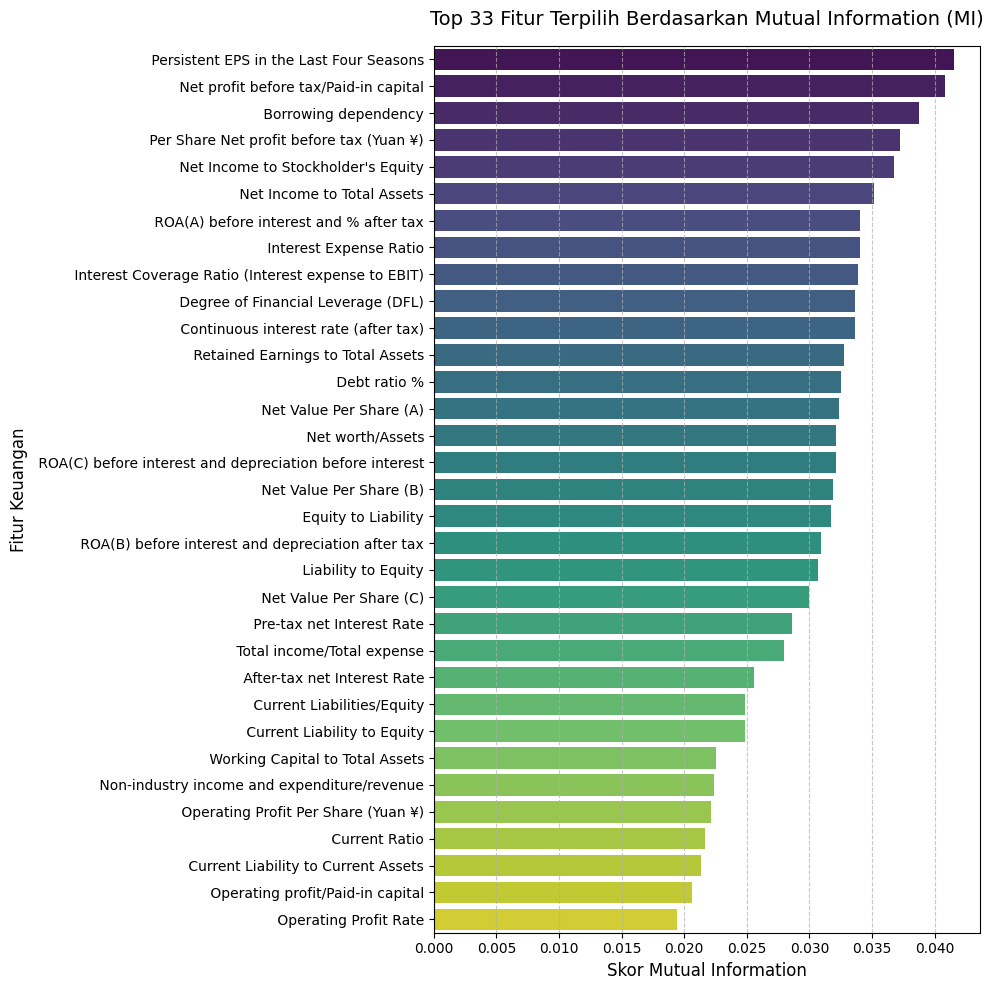

Split data selesai:
x_train_raw: (5455, 95)
x_test_raw : (1364, 95)


In [ ]:
target_col = 'Bankrupt?'

x_raw = df.drop(columns=[target_col])
y = df[target_col]

x_train_raw, x_test_raw, y_train, y_test = train_test_split(
    x_raw,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

median_train = x_train_raw.median()
x_train_raw_filled = x_train_raw.fillna(median_train)
x_test_raw_filled = x_test_raw.fillna(median_train)

# menghitung Mutual Information hanya berdasarkan data training
print("Menghitung Mutual Information...")
mi_scores = mutual_info_classif(
    x_train_raw_filled,
    y_train,
    random_state=42
)

mi_df = pd.DataFrame({
    'Feature': x_train_raw.columns,
    'MI Score': mi_scores
}).sort_values(
    'MI Score',
    ascending=False
)

display(mi_df.head(33))

mi_series = pd.Series(mi_scores, index=x_train_raw.columns).sort_values(ascending=False)

# Visualisasi Barplot berdasarkan 33 fitur terbaik
plt.figure(figsize=(10,10))
sns.barplot(x=mi_series.head(33).values, y=mi_series.head(33).index, palette='viridis')
plt.title('Top 33 Fitur Terpilih Berdasarkan Mutual Information (MI)', fontsize=14, pad=15)
plt.xlabel('Skor Mutual Information', fontsize=12)
plt.ylabel('Fitur Keuangan', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Split data selesai:")
print("x_train_raw:", x_train_raw.shape)
print("x_test_raw :", x_test_raw.shape)

### Berdasarkan Eksplorasi Data tersebut didapati bahwa:


*   Ketidakseimbangan Kelas (Imbalance): Kelas target sangat dominan pada perusahaan sehat (0) sebanyak 93.77%, sedangkan perusahaan bangkrut (1) sebanyak 3.23% porsinya sangat tidak balance.

* Mutual Information(MI): : Dari 95 fitur, terdapat 33 fitur dengan MI ≥ 0,020, dengan Persistent EPS in the Last Four Seasons memiliki skor MI tertinggi sebesar 0,0415.

# 2. Preprocessing

In [ ]:
# Tangani missing value (jika ada) dengan strategi yang sesuai.
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.

print("Jumlah missing value:")
print(df.isnull().sum().sum())

if df.isnull().sum().sum() == 0:
    print("Tidak ada missing value pada dataset.")
else:
    print("Terdapat missing value dan akan ditangani setelah train-test split.")

Jumlah missing value:
0
Tidak ada missing value pada dataset.


In [ ]:
# Jika terdapat fitur kategorikal, lakukan encoding yang sesuai (misalnya One-Hot Encoding atau Ordinal Encoding).
# Catatan: Decision Tree secara konsep bisa menangani fitur kategorikal secara langsung tanpa One-Hot Encoding,
# tetapi implementasi DecisionTreeClassifier pada scikit-learn tetap mengharuskan input berupa angka.

cat_cols = df.select_dtypes(include=['object']).columns

if len(cat_cols) > 0:
    df = pd.get_dummies(
        df,
        columns=cat_cols,
        drop_first=True
    )
    print("Encoding kategorikal selesai.")
else:
    print("Tidak terdapat fitur kategorikal.")

Tidak terdapat fitur kategorikal.


In [ ]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.
target_col = 'Bankrupt?'

x = df.drop(columns=[target_col])
y = df[target_col]

# Bagi data menjadi train dan test
# Stratify digunakan agar proporsi kelas tetap seimbang
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Tangani missing value berdasarkan data training saja
if x_train.isnull().sum().sum() > 0:
    median_train = x_train.median(numeric_only=True)

    x_train = x_train.fillna(median_train)
    x_test = x_test.fillna(median_train)

print(f"Dimensi x_train: {x_train.shape}")
print(f"Dimensi x_test : {x_test.shape}")
print(f"Dimensi y_train: {y_train.shape}")
print(f"Dimensi y_test : {y_test.shape}")

Dimensi x_train: (5455, 95)
Dimensi x_test : (1364, 95)
Dimensi y_train: (5455,)
Dimensi y_test : (1364,)


**Catatan penting:** Decision Tree tidak memerlukan feature scaling (StandardScaler/MinMaxScaler). Split pada Decision Tree dilakukan berdasarkan threshold per fitur satu per satu, bukan berdasarkan jarak antar titik seperti pada KNN atau SVM. Jadi kalian tidak perlu melakukan scaling pada tahap ini.

# 3. Eksperimen Model

## 3.1 Decision Tree dengan Kriteria Gini

Gini Impurity adalah kriteria default pada DecisionTreeClassifier di scikit-learn. Kriteria ini mengukur peluang kesalahan klasifikasi jika sebuah sampel dipilih secara acak dari suatu node.

In [ ]:
# Inisialisasi dan latih model DecisionTreeClassifier dengan criterion='gini'
# Membuat model Decision Tree dengan kriteria Gini

dt_gini = DecisionTreeClassifier(
    criterion='gini',
    random_state=42
)

dt_gini.fit(
    x_train,
    y_train
)

y_pred_gini = dt_gini.predict(
    x_test
)

In [ ]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.

y_pred_gini = dt_gini.predict(x_test)

accuracy_gini = accuracy_score(
    y_test,
    y_pred_gini
)

print(f"Akurasi dengan Gini Impurity: {accuracy_gini:.4f}")

Akurasi dengan Gini Impurity: 0.9604


## 3.2 Decision Tree dengan Kriteria Entropy

Entropy (Information Gain) adalah kriteria alternatif yang mengukur tingkat ketidakpastian distribusi kelas pada suatu node.

In [ ]:
# Inisialisasi dan latih model DecisionTreeClassifier dengan criterion='entropy' menggunakan train set.
# Gunakan nilai hyperparameter lain yang sama seperti model Gini di atas, agar perbandingan adil.

dt_entropy = DecisionTreeClassifier(
    criterion='entropy',
    random_state=42
)

dt_entropy.fit(
    x_train,
    y_train
)

y_pred_entropy = dt_entropy.predict(
    x_test
)

In [ ]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
y_pred_entropy = dt_entropy.predict(x_test)

accuracy_entropy = accuracy_score(
    y_test,
    y_pred_entropy
)

print(f"Akurasi dengan Entropy: {accuracy_entropy:.4f}")

Akurasi dengan Entropy: 0.9641


## 3.3 Eksperimen Regularisasi: Pengaruh max_depth terhadap Overfitting

Decision Tree yang dibiarkan tumbuh tanpa batas cenderung overfitting terhadap data training. Pada bagian ini kalian akan mengamati bagaimana perubahan nilai max_depth memengaruhi akurasi training dan testing.

In [ ]:
# Latih beberapa model DecisionTreeClassifier dengan variasi nilai max_depth,
# misalnya 1, 2, 3, 5, 10, dan None (tanpa batas kedalaman).
# Gunakan kriteria split terbaik dari salah satu percobaan sebelumnya (Gini atau Entropy).
max_depths = [1, 2, 3, 5, 10, None]
train_accuracies = []
test_accuracies = []

In [ ]:
# Hitung akurasi pada train set dan test set untuk setiap nilai max_depth yang dicoba.
# Simpan hasilnya dalam list atau dictionary agar mudah diplot.

for depth in max_depths:

    dt_model = DecisionTreeClassifier(
        criterion='entropy',
        max_depth=depth,
        random_state=42
    )

    dt_model.fit(
        x_train,
        y_train
    )

    y_train_pred = dt_model.predict(x_train)
    y_test_pred = dt_model.predict(x_test)

    train_acc = accuracy_score(
        y_train,
        y_train_pred
    )

    test_acc = accuracy_score(
        y_test,
        y_test_pred
    )

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

print("Hasil Eksperimen max_depth")
print("-" * 60)

for depth, train_acc, test_acc in zip(
    max_depths,
    train_accuracies,
    test_accuracies
):
    depth_str = "None" if depth is None else str(depth)

    print(
        f"Max Depth: {depth_str:4} | "
        f"Train Accuracy: {train_acc:.4f} | "
        f"Test Accuracy: {test_acc:.4f}"
    )

Hasil Eksperimen max_depth
------------------------------------------------------------
Max Depth: 1    | Train Accuracy: 0.9677 | Test Accuracy: 0.9677
Max Depth: 2    | Train Accuracy: 0.9677 | Test Accuracy: 0.9677
Max Depth: 3    | Train Accuracy: 0.9683 | Test Accuracy: 0.9699
Max Depth: 5    | Train Accuracy: 0.9743 | Test Accuracy: 0.9663
Max Depth: 10   | Train Accuracy: 0.9930 | Test Accuracy: 0.9633
Max Depth: None | Train Accuracy: 1.0000 | Test Accuracy: 0.9641


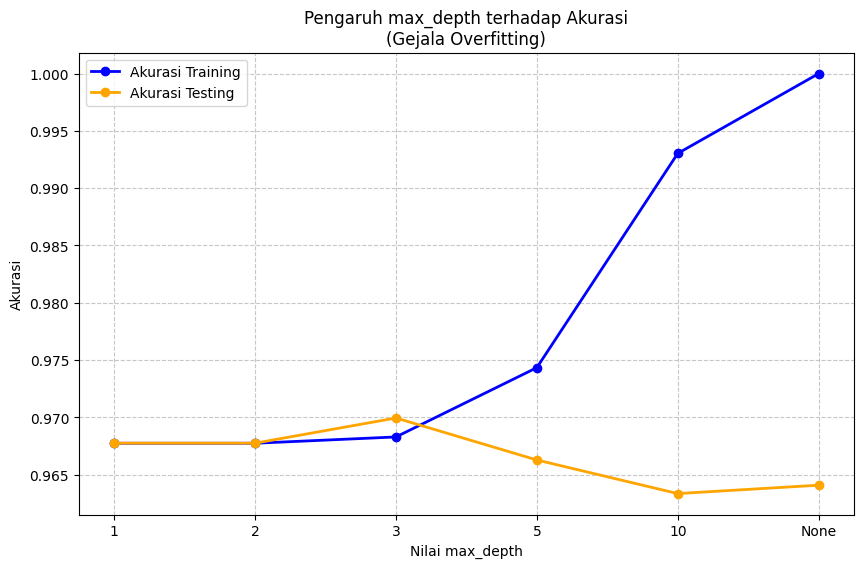

In [ ]:
# Plot grafik akurasi training vs testing terhadap max_depth dalam satu chart.
# Amati pada titik berapa model mulai menunjukkan gejala overfitting
depth_labels = [str(d) if d is not None else 'None' for d in max_depths]

plt.figure(figsize=(10, 6))
plt.plot(depth_labels, train_accuracies, marker='o', label='Akurasi Training', color='blue', linewidth=2)
plt.plot(depth_labels, test_accuracies, marker='o', label='Akurasi Testing', color='orange', linewidth=2)
plt.title('Pengaruh max_depth terhadap Akurasi\n(Gejala Overfitting)')
plt.xlabel('Nilai max_depth')
plt.ylabel('Akurasi')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 4. Evaluasi Model

In [ ]:
# Tampilkan metrik evaluasi (Accuracy, Precision, Recall, F1-Score) untuk model Gini dan Entropy.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.
def evaluate_model(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    return [model_name, acc, prec, rec, f1]

metrics_data = [
    evaluate_model(y_test, y_pred_gini, 'Decision Tree (Gini)'),
    evaluate_model(y_test, y_pred_entropy, 'Decision Tree (Entropy)')
]

metrics_df = pd.DataFrame(metrics_data, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score'])
display(metrics_df)

,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree (Gini),0.960411,0.386364,0.386364,0.386364
1,Decision Tree (Entropy),0.964076,0.435897,0.386364,0.409639


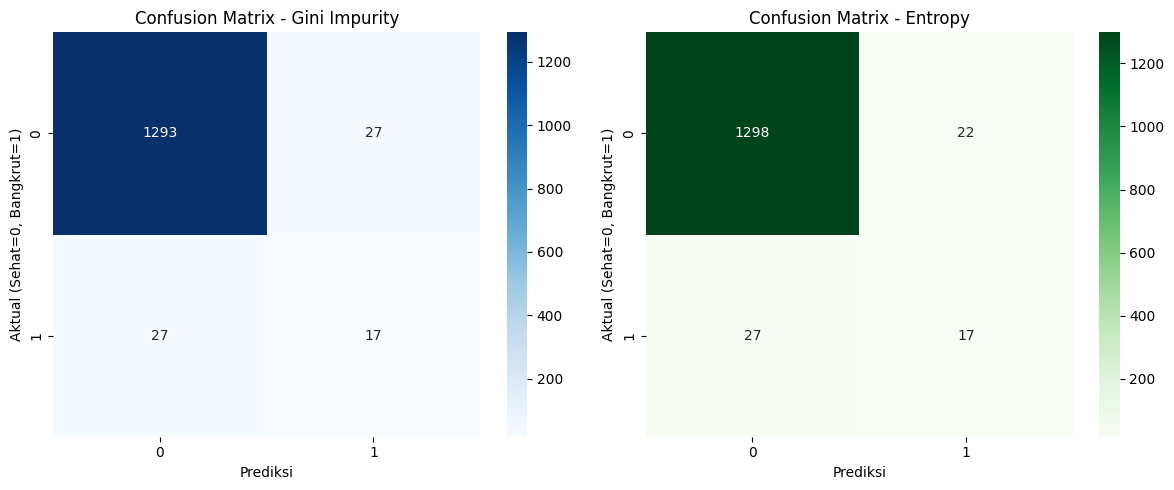

In [ ]:
# Tampilkan Confusion Matrix untuk model Gini dan Entropy dalam bentuk heatmap.
# Susun keduanya dalam satu baris subplot.
cm_gini = confusion_matrix(y_test, y_pred_gini)
cm_entropy = confusion_matrix(y_test, y_pred_entropy)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_gini, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix - Gini Impurity')
axes[0].set_xlabel('Prediksi')
axes[0].set_ylabel('Aktual (Sehat=0, Bangkrut=1)')

sns.heatmap(cm_entropy, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Confusion Matrix - Entropy')
axes[1].set_xlabel('Prediksi')
axes[1].set_ylabel('Aktual (Sehat=0, Bangkrut=1)')

plt.tight_layout()
plt.show()

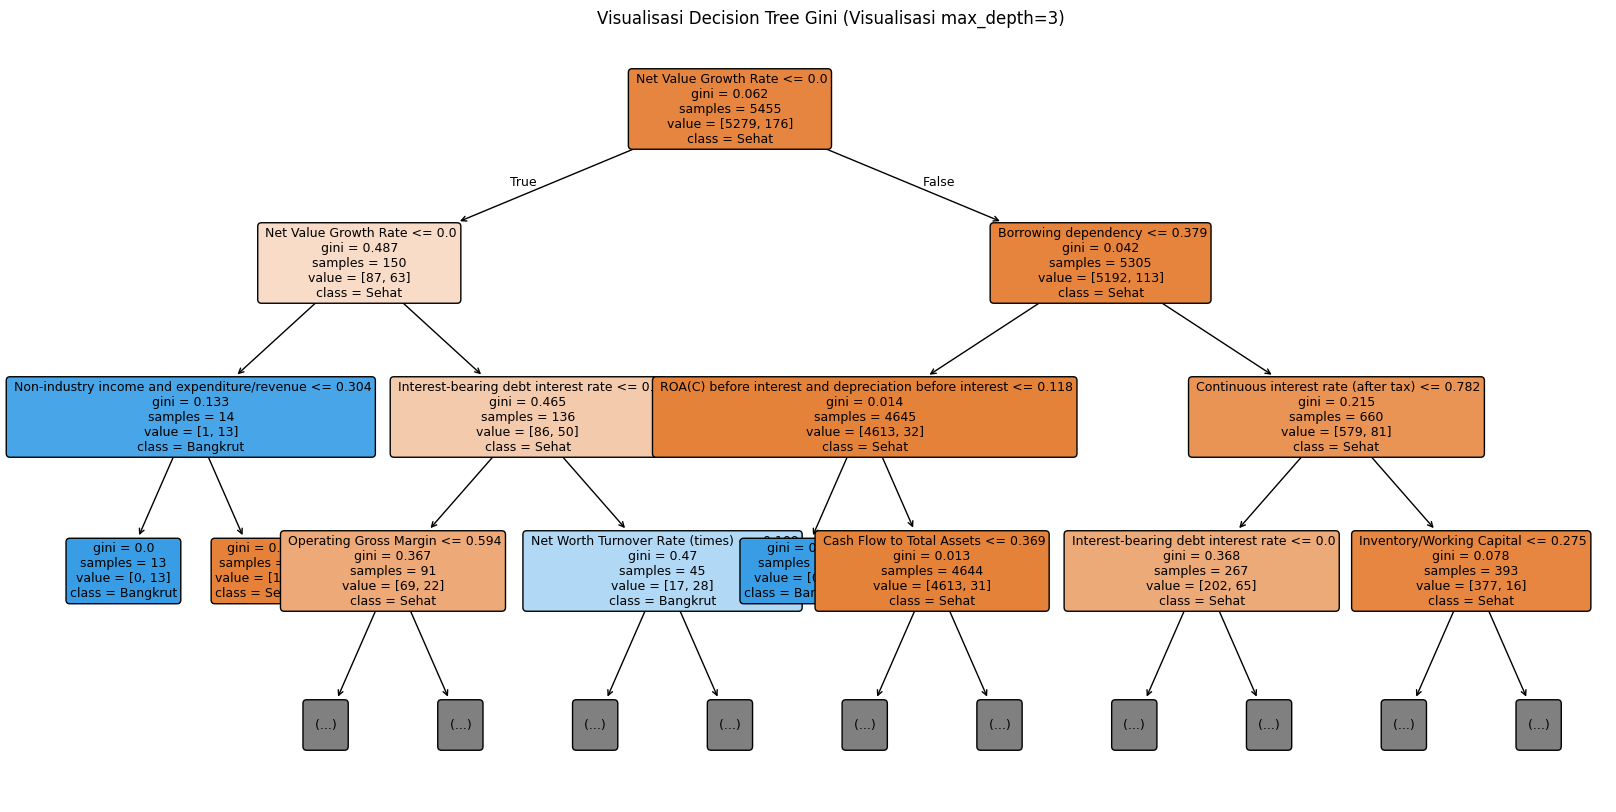

In [ ]:
# Visualisasikan struktur Decision Tree (gunakan plot_tree) untuk model dengan performa terbaik.
# Batasi kedalaman visualisasi (misalnya max_depth=2 atau 3 pada parameter plot_tree) agar tetap mudah dibaca.

plt.figure(figsize=(20, 10))

plot_tree(
    dt_gini,
    feature_names=x_train.columns,
    class_names=['Sehat', 'Bangkrut'],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9
)

plt.title('Visualisasi Decision Tree Gini (Visualisasi max_depth=3)')
plt.show()

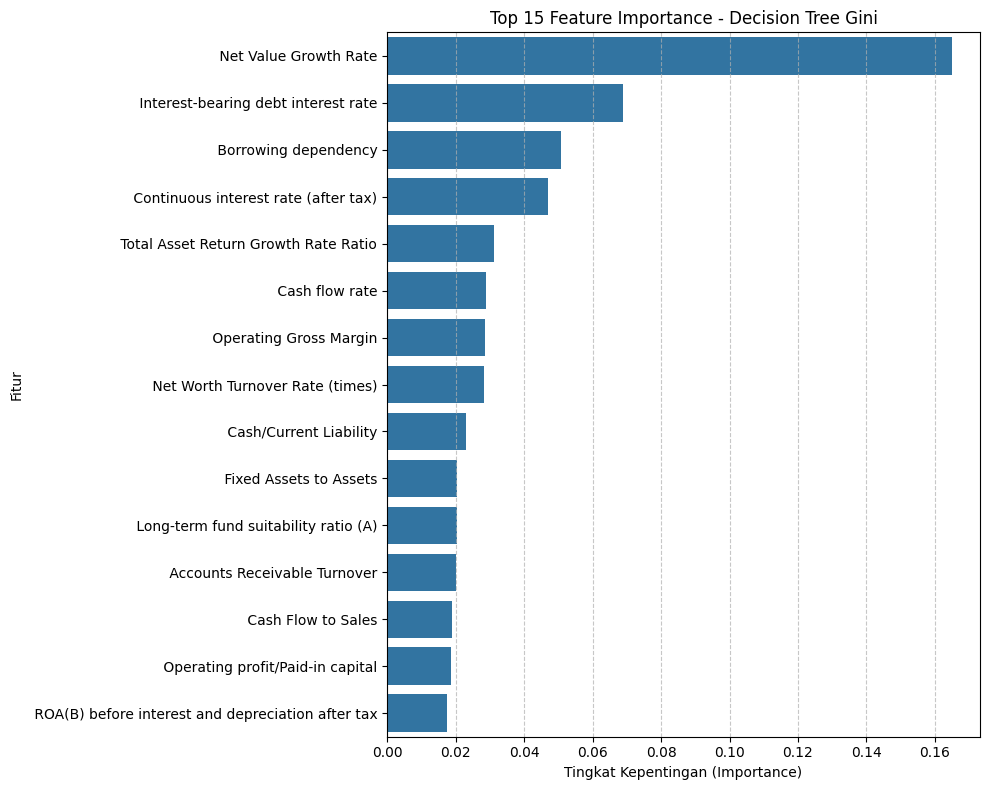

,Fitur,Importance
29,Net Value Growth Rate,0.164899
13,Interest-bearing debt interest rate,0.068829
39,Borrowing dependency,0.050665
9,Continuous interest rate (after tax),0.046977
30,Total Asset Return Growth Rate Ratio,0.031279
12,Cash flow rate,0.029020
3,Operating Gross Margin,0.028564
49,Net Worth Turnover Rate (times),0.028237
58,Cash/Current Liability,0.023187
75,Fixed Assets to Assets,0.020349


In [ ]:
# Tampilkan feature importance dari model terbaik dalam bentuk bar chart horizontal.
# Urutkan dari fitur yang paling berpengaruh.
feature_importances = dt_gini.feature_importances_

feat_imp_df = pd.DataFrame({
    'Fitur': x_train.columns,
    'Importance': feature_importances
}).sort_values(
    by='Importance',
    ascending=False
)

# Tampilkan 15 fitur paling penting
plt.figure(figsize=(10, 8))

sns.barplot(
    x='Importance',
    y='Fitur',
    data=feat_imp_df.head(15)
)

plt.title('Top 15 Feature Importance - Decision Tree Gini')
plt.xlabel('Tingkat Kepentingan (Importance)')
plt.ylabel('Fitur')
plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.7
)

plt.tight_layout()
plt.show()

display(feat_imp_df.head(15))

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan.

Beberapa hal yang perlu dibahas:
- Bandingkan performa Decision Tree dengan kriteria Gini vs Entropy. Apakah hasilnya berbeda signifikan? Menurut kalian, kenapa demikian?
- Jelaskan temuan dari eksperimen regularisasi (max_depth). Pada nilai berapa model mulai menunjukkan gejala overfitting? Bagaimana ciri-cirinya terlihat dari grafik akurasi training vs testing?
- Fitur apa yang paling berpengaruh terhadap prediksi model, berdasarkan feature importance?

Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan, bukan hasil orang lain.

### Analisis

* **Gini vs Entropy:** Hasil pengujian menunjukkan bahwa Decision Tree dengan Gini memperoleh Accuracy 96,04%, sedangkan Entropy 96,41%. Perbedaannya hanya 0,37%, sehingga hasilnya relatif tidak jauh berbeda. Precision dan F1-Score Entropy juga sedikit lebih tinggi, sedangkan Recall keduanya sama-sama 38,64%. Perbedaan yang kecil ini kemungkinan terjadi karena kedua kriteria menghasilkan proses pemisahan data yang cukup mirip pada dataset yang digunakan. Selain itu, dataset memiliki ketidakseimbangan kelas yang tinggi, yaitu 96,77% kelas sehat dan 3,23% kelas bangkrut, sehingga Accuracy juga sangat dipengaruhi oleh kelas mayoritas.

* **Regularisasi `max_depth`:** Gejala **overfitting mulai terlihat pada `max_depth = 5`**, ketika Accuracy training (**97,43%**) mulai lebih tinggi dibandingkan testing (**96,63%**). Pada `max_depth = 10` dan `None`, selisih semakin besar sehingga menunjukkan model semakin overfit.

* **Feature Importance:** Fitur yang paling berpengaruh adalah **Net Value Growth Rate** dengan importance **0,1649**, diikuti **Interest-bearing debt interest rate (0,0688)** dan **Borrowing dependency (0,0507)**.

**Mutual Information (MI):** MI digunakan untuk melihat keterkaitan fitur dengan target. Dari **95 fitur**, terdapat **33 fitur dengan MI ≥ 0,020**. Hasil ini membantu mengetahui fitur yang paling relevan sebelum proses pemodelan.


# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan.

Saran dapat berupa rekomendasi untuk eksperimen selanjutnya (misalnya mencoba pruning dengan ccp_alpha, membandingkan dengan model lain, atau mencoba variasi hyperparameter lain seperti min_samples_leaf), perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

### Kesimpulan

Secara keseluruhan, model Decision Tree mampu menghasilkan akurasi yang tinggi, tetapi ketidakseimbangan data menjadi hal penting dalam interpretasi hasil. Akurasi sekitar 96% belum menunjukkan bahwa model mampu mengenali perusahaan bangkrut dengan baik, terlihat dari Recall kelas bangkrut yang hanya 38,64%.

Penggunaan Mutual Information (MI) membantu mengidentifikasi fitur-fitur yang memiliki hubungan paling kuat dengan target dan dapat dijadikan dasar untuk seleksi fitur pada eksperimen berikutnya. Dari pengujian kriteria split, hasil Entropy sedikit lebih tinggi dibandingkan Gini. Selain itu, eksperimen max_depth menunjukkan bahwa pohon yang terlalu dalam meningkatkan risiko overfitting.

###Saran

Untuk pengembangan selanjutnya, dapat dilakukan penanganan imbalance data, mencoba feature selection berdasarkan hasil MI, serta melakukan tuning seperti min_samples_leaf atau ccp_alpha untuk mengurangi overfitting.